# Background evolution of the field with CLASS
In this notebook we construct the numerical background evolution of an axion field $\chi_0$ and plot it versus redshift $z$. The equation of motion for this field is $$ \chi_0''+2\mathcal{H}\chi_0'+a(\tau)^2\frac{dV}{d\chi_0}=0\, , $$ where $'=\frac{d}{d\tau}$ and $\mathcal{H}$ is the Hubble ratio in conformal time.In this notebook, we will use CLASS in order not to compute numerically $H(a)$ and $a(\tau)$.
We first import all the necessary libraries to compute the background cosmology, solve and plot the results.

In [1]:
import classy as cl
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

With *CLASS*, the only external parameters will simply be the Planck mass and the reduced Planck Mass, $M_{Pl}$ and $m_{Pl}$, since the other cosmological parameters will be defined inside *CLASS*.

In [2]:
ev_to_Mpc=1.5637e29
Mpl=1.22e28*ev_to_Mpc
mpl=Mpl/np.sqrt(8*np.pi)

Now we use *CLASS* to obtain the evolution of different quantities depending on the cosmological parameters that we input. In this case we used fiducial values for them. To make sure of the units and the quantities, we printed the first line of the table that *CLASS* generates. We will be interested in:
- the conformal time $\tau$
- the redshift $z$
- and the Hubble rate $H$.

These will then be used to compute the scale factor $a$ and, after that, the conformal Hubble rate $\mathcal{H}$.\
To these parameters, we will add:
- the critical density $\rho_{crit}$
- the density paramter for matter $\Omega_m$
- the one for radiation $\Omega_r$
- and the one for $\Lambda$ $\Omega_\Lambda$

that will be useful later, together with their values now $\Omega_{m,\, 0}$, $\Omega_{r,\, 0}$ and $\Omega_{\Lambda,\, 0}$. It is important to state that, since the axion field is considered a spectator field, it is not necessary to modify the contribution of the different densityu parameters inside the expression for $\mathcal{H}(a)$, and, therefore, we can simply use the one produced by *CLASS*.

In [3]:
cosmo=cl.Class()
parameters={'h':0.6736, 'omega_b':0.02237, 'omega_cdm':0.12, 'A_s':2.1e-9, 'n_s':0.965, 'tau_reio':0.054}
cosmo.set(parameters)
cosmo.compute()
bg=cosmo.get_background()
print(bg.keys())

rhocrit=np.array(bg['(.)rho_crit'])
Omegam=(np.array(bg['(.)rho_b'])+np.array(bg['(.)rho_cdm']))/rhocrit
Omegar=(np.array(bg['(.)rho_g'])+np.array(bg['(.)rho_ur']))/rhocrit
OmegaL=np.array(bg['(.)rho_lambda'])/rhocrit

rhocrit0=rhocrit[-1]
Omegam0=Omegam[-1]
Omegar0=Omegar[-1]
OmegaL0=OmegaL[-1]

print(r'$\Omega_{m,\, 0}=$', Omegam0)
print(r'$\Omega_{rad,\, 0}=$', Omegar0)
print(r'$\Omega_{\Lambda,\, 0}=$', OmegaL0)

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
$\Omega_{m,\, 0}=$ 0.31377210267376066
$\Omega_{rad,\, 0}=$ 9.218085625176577e-05
$\Omega_{\Lambda,\, 0}=$ 0.6861357164699877


We extract the quantities mentioned before and transform $H$ into $\mathcal{H}$ by multiplying it by $a$.

In [4]:
tau=np.array(bg['conf. time [Mpc]'])
z=np.array(bg['z'])
a=np.array(1/(1+z))
H=np.array(bg['H [1/Mpc]'])
H_conformal=a*H

To compute the EOM I need to interpolate the points given by CLASS because *ScyPy* will require more points that are much closer to each other to compute the differential equation.  After that, we also need to write, as in the other case, the derivative of the potential for the differential equation.

In [5]:
a_func_tau=sp.interpolate.interp1d(tau, a)
H_func_tau=sp.interpolate.interp1d(tau, H_conformal)

def V(x0, mx):
    return Mpl**2*mx**2*(1-np.cos(x0/Mpl))**2
def V_prime(x0, mx):
    return 2*Mpl*mx**2*np.sin(x0/Mpl)*(1-np.cos(x0/Mpl))
def eom(tau, y, mx):
    x0, vx=y
    return [vx, -2*H_func_tau(tau)*vx-a_func_tau(tau)**2*V_prime(x0, mx)]

From here on, the computation requires to input everything computed up to now in the differetial equation calculator, find $\chi_0(\tau)$ for each value of $m_\chi$ and then convert it into $\chi_0(z)$ for the plot.\
The small function *LaTeX_mass* is just used to retreive the value of $m_\chi$ in eV for the plot, since all the computations are done with the units that are used in *CLASS*.

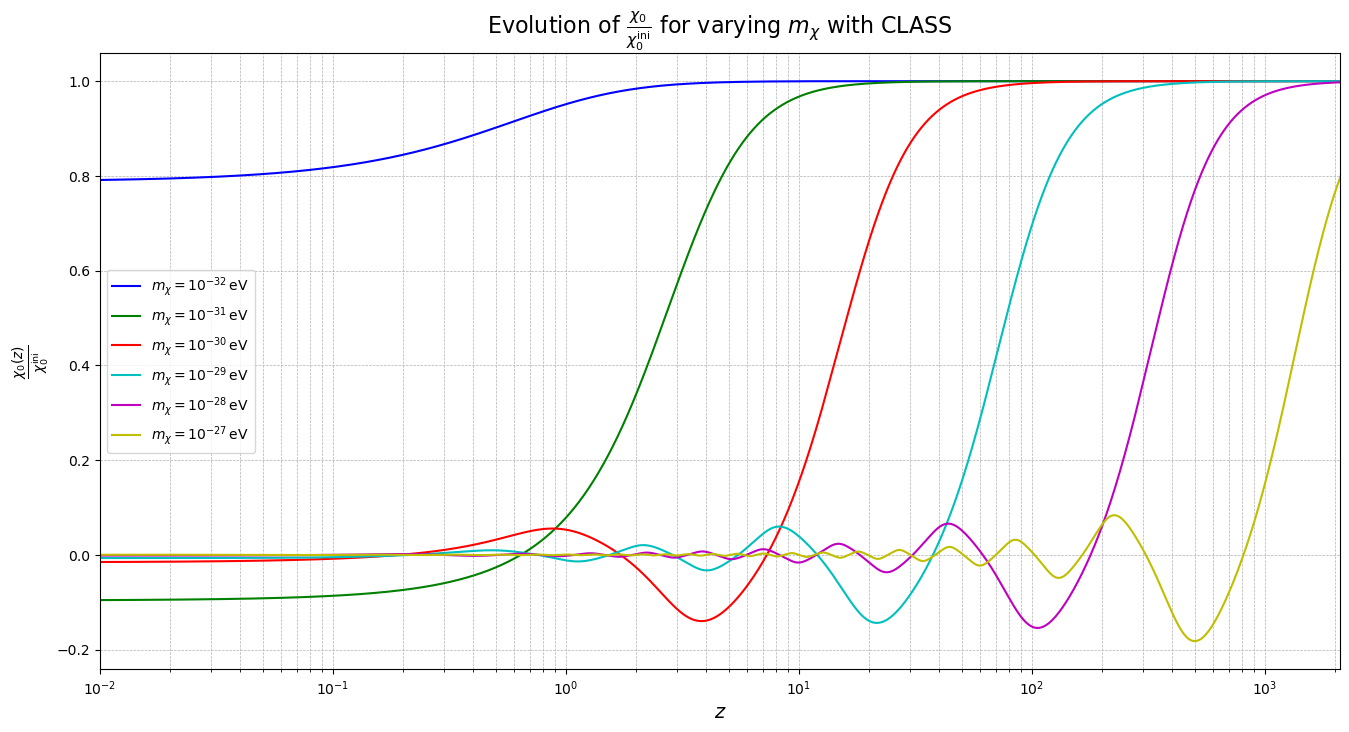

In [6]:
mx_values_Mpc=np.logspace(-32, -27, 6)*ev_to_Mpc

def LaTex_mass(mx_values):
    exp = int(np.log10(mx_values/(ev_to_Mpc)))
    return rf'10^{{{exp}}}\,\mathrm{{eV}}'

colors=['b', 'g', 'r', 'c', 'm', 'y']

plt.figure(figsize=(16, 8))
plt.xscale('log')

for mx_Mpc, col in zip(mx_values_Mpc, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)
    x0_solution=solution.sol(tau)[0]/initial_conditions[0]

    plt.plot(z, x0_solution, color=col, label=rf'$m_\chi={LaTex_mass(mx_Mpc)}$')
    



plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylabel(r'$\frac{\chi_0(z)}{\chi_0^{\mathrm{ini}}}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\frac{\chi_0}{\chi_0^{\rm ini}}$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show()

The graph matches pretty well the one in the paper "Probing Axions through Tomography of Anisotropic Cosmic Birefringence", as we were hoping for. 

Moreover, it is possible to compute the value of $\omega_{\chi_0}$, i.e. the ratio of the equation of state of $\chi_0$. To do so we can simply take the second result given by the integration of the equation of motion, $\chi_0'(\tau)=v_{\chi_0}$, and using the formula $$ \omega_{\chi_0}=\frac{\chi_0'-2a^2V(\chi_0)}{\chi_0'+2a^2V(\chi_0)}\, ,$$ we get the evolution of omega in redshift. 

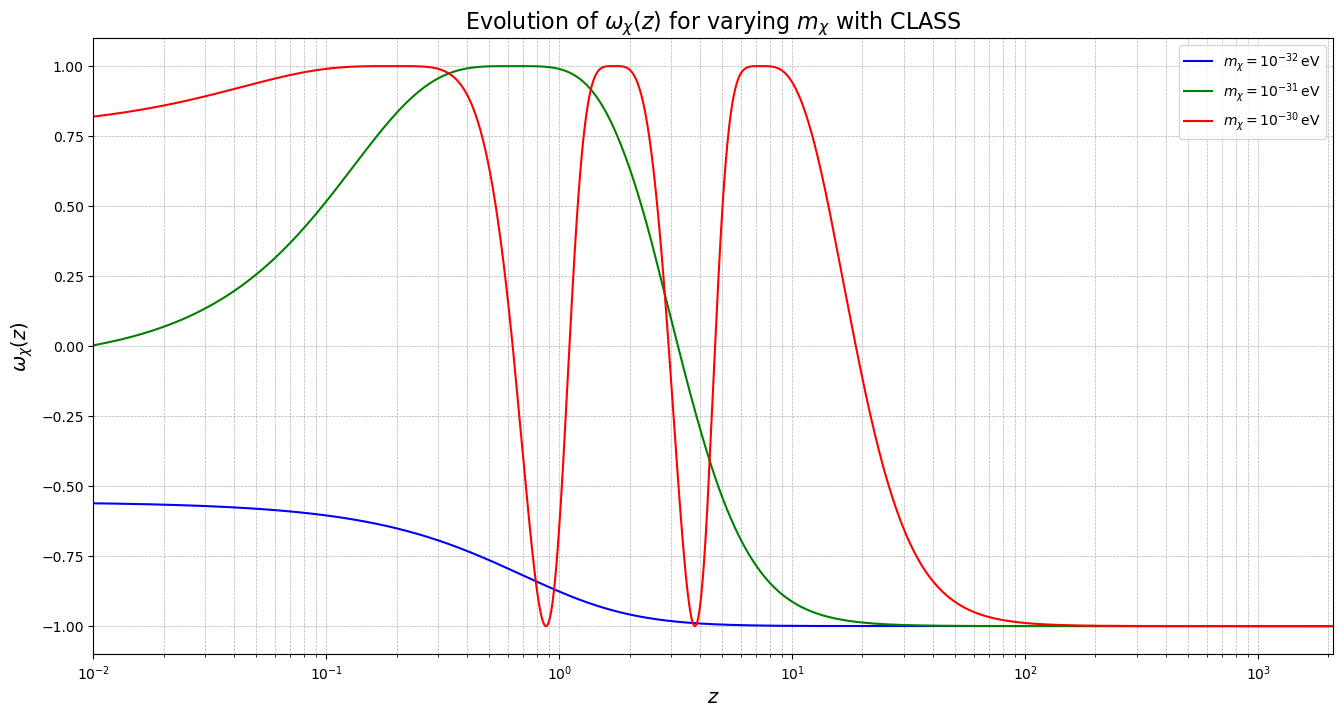

In [7]:
plt.figure(figsize=(16, 8))
plt.xscale('log')


mx_values_Mpc=np.logspace(-32, -30, 3)*ev_to_Mpc
for mx_Mpc, col in zip(mx_values_Mpc, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)

    vx_solution=solution.sol(tau)[1]
    omega=(vx_solution**2-2*a_func_tau(tau)**2*V(solution.sol(tau)[0], mx_Mpc))/(vx_solution**2+2*a_func_tau(tau)**2*V(solution.sol(tau)[0], mx_Mpc))
    plt.plot(z, omega, color=col, label=rf'$m_\chi={LaTex_mass(mx_Mpc)}$') 


plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylabel(r'$\omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\omega_\chi(z)$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show() 

Also here, the result show a very similar beahvior to the ones in the paper.

We can now proceed with the computation of the density parameter of the axion field. In this case, we obtained the values for matter, radiation and $\Lambda$ directly from *CLASS* at the beginning of the code. Additionally, for the matter one we need to account for both barions $(\rho_b)$ and cold dark matter $(\rho_{cdm})$. Similarly for the energy density of radiation, in which we need to account for both photons $(\rho_g)$ and neutrinos $(\rho_{ur})$.

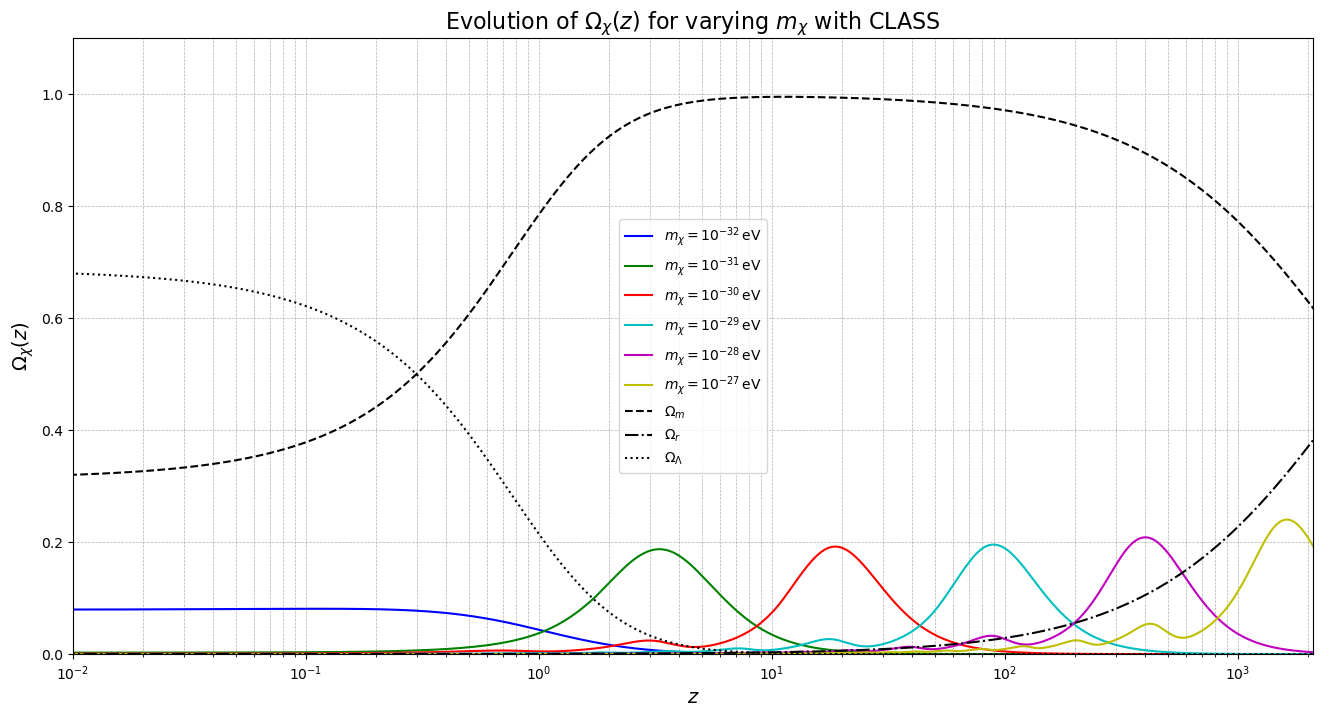

In [8]:
plt.figure(figsize=(16, 8))
plt.xscale('log')

mx_values_Mpc=np.logspace(-32, -27, 6)*ev_to_Mpc

for mx_Mpc, col in zip(mx_values_Mpc, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)
    vx_solution=solution.sol(tau)[1]

    rhox=0.5*(vx_solution/a_func_tau(tau))**2+V(solution.sol(tau)[0], mx_Mpc)
    Omegax=rhox/(3*mpl**2*rhocrit)
    plt.plot(z, Omegax, color=col, label=rf'$m_\chi={LaTex_mass(mx_Mpc)}$')

plt.plot(z, Omegam, 'k--', label=r'$\Omega_m$')
plt.plot(z, Omegar, 'k-.', label=r'$\Omega_r$')
plt.plot(z, OmegaL, 'k:', label=r'$\Omega_\Lambda$')
plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylim(0, 1.1)
plt.ylabel(r'$\Omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\Omega_\chi(z)$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show()

In conclusion, this result properly reproduces the one of the paper.